<a href="https://colab.research.google.com/github/lyntos/Python-MS/blob/main/07_Coding_Project_NLP_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 Capstone - NLP Mini-Project
This notebook walks through a complete NLP workflow:
- Data collection
- Preprocessing (tokenization, stopwords, stemming, lemmatization)
- POS tagging
- Sentiment analysis
- Language detection + translation (TextBlob)
- Spell checking (TextBlob)
- Word definitions, synonyms, antonyms (WordNet)
- Word clouds
- Named Entity Recognition (spaCy) + similarity
- Readability (Textatistic)

**Note:** Some steps (notably translation) require internet access because TextBlob uses online translation services.
If you're running in a restricted environment, those cells will catch errors and continue.

## 0) Setup: Install and import dependencies
Run the next cell once. It installs missing packages and downloads required language resources/models.
If your environment already has them, it will skip installation.

Packages used: `nltk`, `textblob`, `spacy`, `wordcloud`, `langdetect`, `textatistic`, `pandas`, `numpy`.

In [ ]:

# If you are on a fresh environment, uncomment and run:
!pip -q install nltk textblob spacy wordcloud langdetect textatistic

# spaCy model (English). This download requires internet.
# If you already have the model installed, this will do nothing.
!python -m spacy download en_core_web_sm

import re
import math
import random
from collections import Counter

import numpy as np
import pandas as pd

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, movie_reviews, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer

from textblob import TextBlob

import spacy
from wordcloud import WordCloud

# Optional (installed via pip above)
try:
  from langdetect import detect
except Exception as e:
  detect = None
  print("langdetect not available:", e)

try:
  from textatistic import Textatistic
except Exception as e:
  Textatistic = None
  print("textatistic not available:", e)

# NLTK resources (download as needed)
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("movie_reviews", quiet=True)

try:
  nlp = spacy.load("en_core_web_sm")
except Exception as e:
  nlp = None
  print("spaCy model not loaded. Run: python -m spacy download en_core_web_sm\nError:", e)

print("Setup complete.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 16.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 96.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Setup complete.


## 1) Data Collection
**NLTK movie_reviews** dataset (2,000 labeled movie reviews: `pos` or `neg`).

In [ ]:

# Load NLTK movie reviews
documents = []
for category in movie_reviews.categories():
  for fileid in movie_reviews.fileids(category):
    text = movie_reviews.raw(fileid)
    documents.append({"text": text, "label": category})

df = pd.DataFrame(documents)

# Sample for speed (adjust n as you like)
df_sample = df.sample(n=300, random_state=42).reset_index(drop=True)

# Add a few multilingual snippets (for language detection/translation demo)
extra = pd.DataFrame([
  {"text": "C'est un très bon film, j'ai adoré l'histoire et les acteurs.", "label": "unknown"},
  {"text": "Este producto es terrible, no lo recomiendo a nadie.", "label": "unknown"},
  {"text": "Das war unglaublich gut, ich würde es wieder ansehen.", "label": "unknown"},
  {"text": "I luv this moovie so much!!! Its amazng", "label": "unknown"},  # for spellcheck demo
])

df_sample = pd.concat([df_sample, extra], ignore_index=True)

df_sample.head(5)


,text,label
0,the verdict : spine-chilling drama from horror...,pos
1,""" the 44 caliber killer has struck again . "" ...",neg
2,in the company of men made a splash at the sun...,pos
3,"in the year 2029 , captain leo davidson ( mark...",neg
4,[note that followups are directed to rec . art...,pos


## 2) Data Preprocessing

- lowercase
- remove non-letter characters (keep spaces)
- tokenize into words and sentences
- remove stop words
- stemming (Porter)
- lemmatization (WordNet)

In [ ]:
import nltk
nltk.download('punkt_tab')

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def clean_text(text):
  # Lowercase and keep letters/spaces for a simple baseline
  text = text.lower()
  text = re.sub(r"[^a-z\s']", " ", text)  # keep apostrophes for contractions
  text = re.sub(r"\s+", " ", text).strip()
  return text

def preprocess(text):
  cleaned = clean_text(text)
  sentences = sent_tokenize(cleaned)
  tokens = word_tokenize(cleaned)

  # Remove stop words and very short tokens
  tokens_nostop = [t for t in tokens if t not in stop_words and len(t) > 2]

  stems = [stemmer.stem(t) for t in tokens_nostop]
  lemmas = [lemmatizer.lemmatize(t) for t in tokens_nostop]

  return {
    "cleaned": cleaned,
    "sentences": sentences,
    "tokens": tokens,
    "tokens_nostop": tokens_nostop,
    "stems": stems,
    "lemmas": lemmas
  }

processed = df_sample["text"].apply(preprocess)
proc_df = pd.concat([df_sample, processed.apply(pd.Series)], axis=1)

proc_df[["text", "label", "cleaned", "tokens_nostop", "stems", "lemmas"]].head(3)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,text,label,cleaned,tokens_nostop,stems,lemmas
0,the verdict : spine-chilling drama from horror...,pos,the verdict spine chilling drama from horror m...,"[verdict, spine, chilling, drama, horror, maes...","[verdict, spine, chill, drama, horror, maestro...","[verdict, spine, chilling, drama, horror, maes..."
1,""" the 44 caliber killer has struck again . "" ...",neg,the caliber killer has struck again starring j...,"[caliber, killer, struck, starring, john, legu...","[calib, killer, struck, star, john, leguizamo,...","[caliber, killer, struck, starring, john, legu..."
2,in the company of men made a splash at the sun...,pos,in the company of men made a splash at the sun...,"[company, men, made, splash, sundance, film, f...","[compani, men, made, splash, sundanc, film, fe...","[company, men, made, splash, sundance, film, f..."


## 3) Parts-of-Speech (POS) Tagging

In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

def pos_tag_sentence(sentence):
  tokens = word_tokenize(sentence)
  return nltk.pos_tag(tokens)

example_sentence = proc_df.loc[0, "sentences"][0] if proc_df.loc[0, "sentences"] else proc_df.loc[0, "cleaned"]
tags = pos_tag_sentence(example_sentence)
tags[:25]


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


[('the', 'DT'),
 ('verdict', 'NN'),
 ('spine', 'NN'),
 ('chilling', 'VBG'),
 ('drama', 'NN'),
 ('from', 'IN'),
 ('horror', 'JJ'),
 ('maestro', 'NN'),
 ('stephen', 'NN'),
 ('king', 'VBG'),
 ('featuring', 'VBG'),
 ('an', 'DT'),
 ('outstanding', 'JJ'),
 ('oscar', 'NN'),
 ('winning', 'VBG'),
 ('performance', 'NN'),
 ('from', 'IN'),
 ('kathy', 'JJ'),
 ('bates', 'NNS'),
 ('geez', 'VBP'),
 ('french', 'JJ'),
 ('and', 'CC'),
 ('saunders', 'NNS'),
 ('had', 'VBD'),
 ('a', 'DT')]

## 4) Sentiment Analysis (TextBlob)

- polarity > 0.05 → **positive**
- polarity < -0.05 → **negative**
- otherwise → **neutral**

This can help summarize the emotional tone of text, track changes over time, or compare groups.

In [ ]:

def sentiment_label(polarity, pos_thresh=0.05, neg_thresh=-0.05):
  if polarity > pos_thresh:
    return "positive"
  if polarity < neg_thresh:
    return "negative"
  return "neutral"

def textblob_sentiment(text):
  blob = TextBlob(text)
  pol = float(blob.sentiment.polarity)
  subj = float(blob.sentiment.subjectivity)
  return pol, subj, sentiment_label(pol)

sentiments = proc_df["cleaned"].apply(lambda t: pd.Series(textblob_sentiment(t), index=["polarity","subjectivity","sentiment"]))

sent_df = pd.concat([proc_df, sentiments], axis=1)
sent_df[["label","polarity","subjectivity","sentiment"]].head(10)


,label,polarity,subjectivity,sentiment
0,pos,0.140728,0.568982,positive
1,neg,0.085012,0.462305,positive
2,pos,0.052376,0.465554,positive
3,neg,0.180324,0.526723,positive
4,pos,0.159236,0.432379,positive
5,pos,0.186065,0.498688,positive
6,neg,0.060507,0.532047,positive
7,pos,0.122374,0.531491,positive
8,neg,-0.009524,0.533696,neutral
9,pos,0.108544,0.470482,positive


### Sentiment summary (counts)

In [ ]:

sent_df["sentiment"].value_counts()


,count
sentiment,
positive,213
neutral,75
negative,16


## 5) Language Detection and Translation (TextBlob)

- Detect language (using `langdetect` if available; otherwise try TextBlob's `detect_language()`)
- Translate non-English samples to English using `TextBlob(...).translate(to='en')`

In [ ]:

def detect_lang(text):
  # Prefer langdetect (offline), fallback to TextBlob (usually online)
  if detect is not None:
    try:
      return detect(text)
    except Exception:
      return "unknown"
  try:
    return TextBlob(text).detect_language()
  except Exception:
    return "unknown"

def translate_to_english(text):
  try:
    return str(TextBlob(text).translate(to="en"))
  except Exception as e:
    return f"[Translation failed: {e}]"

demo_rows = sent_df.tail(4).copy()  # our extra multilingual + misspelling line
demo_rows["detected_language"] = demo_rows["text"].apply(detect_lang)
demo_rows["translated_en"] = demo_rows.apply(
  lambda r: translate_to_english(r["text"]) if r["detected_language"] not in ["en","unknown"] else r["text"],
  axis=1
)

demo_rows[["text","detected_language","translated_en"]]


,text,detected_language,translated_en
300,"C'est un très bon film, j'ai adoré l'histoire ...",fr,[Translation failed: 'TextBlob' object has no ...
301,"Este producto es terrible, no lo recomiendo a ...",es,[Translation failed: 'TextBlob' object has no ...
302,"Das war unglaublich gut, ich würde es wieder a...",de,[Translation failed: 'TextBlob' object has no ...
303,I luv this moovie so much!!! Its amazng,en,I luv this moovie so much!!! Its amazng


## 6) Spell Checking and Correction (TextBlob)
Corrects "moovie" to "movie".

In [ ]:

spell_demo = sent_df[sent_df["text"].str.contains("moovie", case=False, na=False)].head(1)

if len(spell_demo) == 0:
  print("No spell-demo row found.")
else:
  original = spell_demo.iloc[0]["text"]
  corrected = str(TextBlob(original).correct())
  print("Original :", original)
  print("Corrected:", corrected)


Original : I luv this moovie so much!!! Its amazng
Corrected: I lui this movie so much!!! Its amazing


## 7) Word Definitions, Synonyms, and Antonyms (WordNet)

- definitions
- synonyms
- antonyms (when available)

In [ ]:

# Choose top words from the dataset (after stop-word removal)
all_tokens = []
for toks in proc_df["tokens_nostop"]:
  all_tokens.extend(toks)

top_words = [w for w, _ in Counter(all_tokens).most_common(10)]
top_words


['film',
 "n't",
 'one',
 'movie',
 'like',
 'good',
 'even',
 'would',
 'time',
 'character']

In [ ]:

def wordnet_info(word, max_items=5):
  synsets = wordnet.synsets(word)
  if not synsets:
    return {"word": word, "definitions": [], "synonyms": [], "antonyms": []}

  definitions = []
  synonyms = set()
  antonyms = set()

  for syn in synsets:
    if syn.definition() not in definitions:
      definitions.append(syn.definition())

    for lemma in syn.lemmas():
      synonyms.add(lemma.name().replace("_"," "))
      for ant in lemma.antonyms():
        antonyms.add(ant.name().replace("_"," "))

  return {
    "word": word,
    "definitions": definitions[:max_items],
    "synonyms": sorted(list(synonyms))[:max_items],
    "antonyms": sorted(list(antonyms))[:max_items]
  }

info = [wordnet_info(w) for w in top_words[:5]]
pd.DataFrame(info)


,word,definitions,synonyms,antonyms
0,film,[a form of entertainment that enacts a story b...,"[celluloid, cinema, film, flick, motion picture]",[]
1,n't,[],[],[]
2,one,[the smallest whole number or a numeral repres...,"[1, I, ace, ane, i]",[]
3,movie,[a form of entertainment that enacts a story b...,"[film, flick, motion picture, motion-picture s...",[]
4,like,"[a similar kind; ,, a kind of person, prefer o...","[alike, care, comparable, corresponding, ilk]","[dislike, unalike, unlike]"


## 8) Word Clouds
Generate a word cloud from the most common words (after stop-word removal).

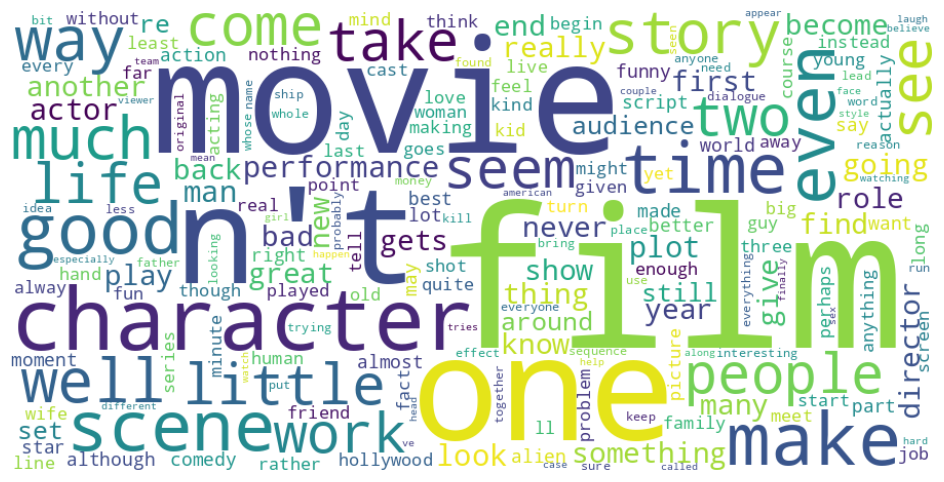

In [ ]:

text_for_cloud = " ".join(all_tokens)

wordcloud = WordCloud(width=900, height=450, background_color="white").generate(text_for_cloud)

# Display
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


## 9) Named Entity Recognition (NER) and Similarity Detection (spaCy)
NER identifies real-world entities like PERSON, ORG, GPE, DATE, etc.
Similarity compares two documents and returns a similarity score.

`en_core_web_sm` does not include large word vectors, so similarity may be less accurate - this is the same issue I faced in class during my presentation/seminar.
I will experiment with `en_core_web_md` or `en_core_web_lg`.

In [ ]:

if nlp is None:
  print("spaCy model not available. Install: python -m spacy download en_core_web_sm")
else:
  # Pick a couple documents
  doc_a = nlp(sent_df.loc[0, "cleaned"][:2000])
  doc_b = nlp(sent_df.loc[1, "cleaned"][:2000])

  # Show entities from doc_a
  ents = [(ent.text, ent.label_) for ent in doc_a.ents]
  print("Sample entities (doc 0):")
  print(ents[:15])

  # Similarity
  sim = doc_a.similarity(doc_b)
  print("\nSimilarity between doc 0 and doc 1:", sim)


Sample entities (doc 0):
[('stephen king', 'PERSON'), ('french', 'NORP'), ('a field day', 'DATE'), ('british', 'NORP'), ('french', 'NORP'), ('british', 'NORP'), ('a few years', 'DATE'), ('french', 'NORP'), ('jennifer saunder', 'PERSON'), ('stephen king', 'PERSON'), ('phil sheldon james caan', 'PERSON'), ('one', 'CARDINAL')]

Similarity between doc 0 and doc 1: 0.9167065024375916


/tmp/ipython-input-319/3804082932.py:14: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Doc.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use context-sensitive tensors. You can always add your own word vectors, or use one of the larger models instead if available.
  sim = doc_a.similarity(doc_b)


## 10) Text Readability (Textatistic)
Compute readability metrics like Flesch Reading Ease.
If `textatistic` isn't installed, install it with pip first.

In [ ]:

if Textatistic is None:
  print("textatistic not available. Run: pip install textatistic")
else:
  sample_text = sent_df.loc[0, "text"][:3000]
  stats = Textatistic(sample_text)
  # Common metrics
  print("Flesch Reading Ease:", stats.flesch_score)
  print("Flesch-Kincaid Grade:", stats.fleschkincaid_score)
  print("Dale-Chall Score:", stats.dalechall_score)


Flesch Reading Ease: 72.64663934426231
Flesch-Kincaid Grade: 7.45632318501171
Dale-Chall Score: 9.74271943793911
